In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
from dawn.models.system1.raft import RAFT
from dawn.data.calvin.calvin import CalvinDataset

/home/nero/miniforge3/envs/dawn/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nero/miniforge3/envs/dawn/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [92]:
dataset = CalvinDataset(
        data_path="/home/nero/Robotics/DAWN/data/calvin/dataset_opt/calvin_debug_dataset", 
        split="training"
    )

2025-06-11 16:33:42,518 - INFO - dawn.data.calvin.calvin - Loaded 9 episodes from /home/nero/Robotics/DAWN/data/calvin/dataset_opt/calvin_debug_dataset/training/episodes
2025-06-11 16:33:42,519 - INFO - dawn.data.calvin.calvin - Loaded 0 frames in total from /home/nero/Robotics/DAWN/data/calvin/dataset_opt/calvin_debug_dataset/training/episodes
2025-06-11 16:33:42,519 - INFO - dawn.data.calvin.calvin - Loading from /home/nero/Robotics/DAWN/data/calvin/dataset_opt/calvin_debug_dataset takes 0.02 seconds.


In [93]:
from torch.utils.data import DataLoader
dataloader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [94]:
model = RAFT()

2025-06-11 16:33:42,591 - INFO - dawn.models.system1.raft - Initializing RAFT.


In [95]:
import matplotlib.pyplot as plt
def visualize_flow_vectors(image, flow, step=16, save_path=None, title="Optical Flow Vectors"):
    """
    Overlay optical flow vectors on an image.

    Parameters:
        image (numpy.ndarray): Input image (H, W, 3).
        flow (numpy.ndarray): Optical flow array (H, W, 2).
        step (int): Sampling step for displaying flow vectors.

    Returns:
        None (displays the visualization).
    """
    h, w = flow.shape[:2]
    y, x = np.mgrid[step // 2 : h : step, step // 2 : w : step].astype(np.int32)
    fx, fy = flow[x, y].T

    # Overlay flow vectors
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.quiver(x, y, fx, fy, color="red", angles="xy", scale_units="xy", scale=1, width=0.002)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    else:
        plt.show()


In [96]:
from PIL import Image
import numpy as np
def unnormalize(normalized_flow):
    """
    Unnormalize the flow tensor from the range [0, 1] back to the original range.

    Args:
        normalized_flow (numpy.ndarray): The normalized flow tensor of shape (B, H, W, 2).

    Returns:
        numpy.ndarray: The unnormalized flow tensor of the same shape.
    """
    h, w = normalized_flow.shape[-2:]
    flow = np.zeros_like(normalized_flow, dtype=np.float32)
    # Unnormalize channel 0 (height)
    flow[..., 0] = (normalized_flow[..., 0] * 2 * h) - h
    # Unnormalize channel 1 (width)
    flow[..., 1] = (normalized_flow[..., 1] * 2 * w) - w
    return flow

from torchvision.utils import flow_to_image

torch.Size([9, 2, 3, 128, 128])
torch.Size([2, 3, 128, 128])


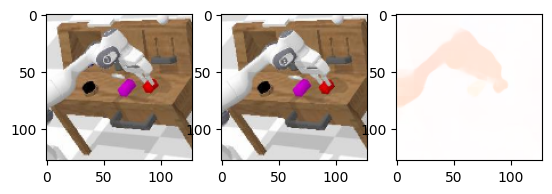

torch.Size([2, 3, 128, 128])


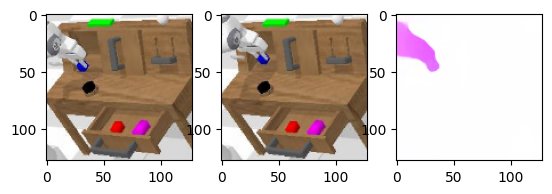

torch.Size([2, 3, 128, 128])


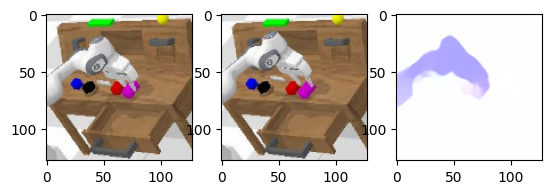

torch.Size([2, 3, 128, 128])


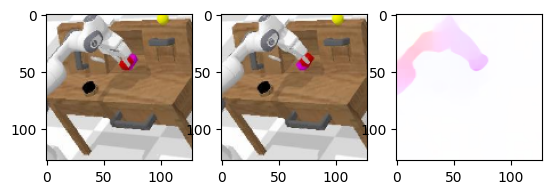

torch.Size([2, 3, 128, 128])


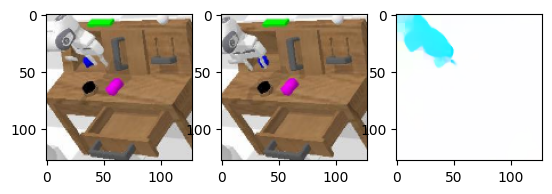

torch.Size([2, 3, 128, 128])


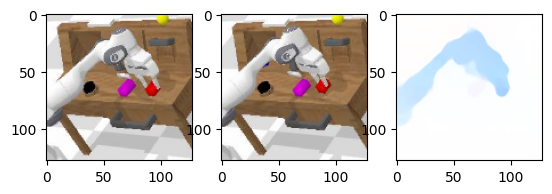

torch.Size([2, 3, 128, 128])


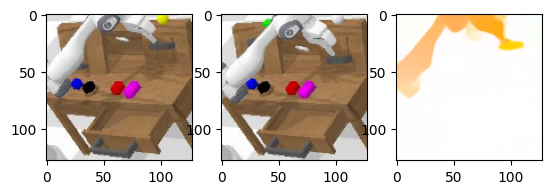

torch.Size([2, 3, 128, 128])


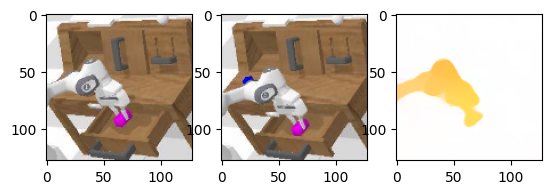

torch.Size([2, 3, 128, 128])


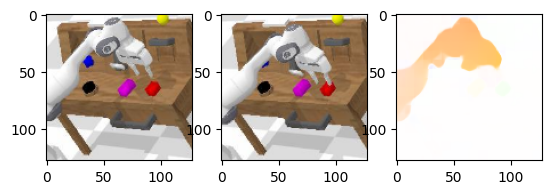

In [97]:
for batch in dataloader:
    print(batch["rgb_static"].shape)
    flow = model(batch)
    
    flow = flow_to_image(flow)
    flow_np = flow.permute(0, 2, 3, 1).cpu().numpy().astype(np.uint8)

    for i in range(flow_np.shape[0]):
        print(batch["rgb_static"][i].shape)
        imgs = batch["rgb_static"][i].permute(0, 2, 3, 1).cpu().numpy()

        plt.subplot(1, 3, 1)
        plt.imshow(imgs[0])
        plt.subplot(1, 3, 2)
        plt.imshow(imgs[1])
        plt.subplot(1, 3, 3)
        plt.imshow(flow_np[i])
        plt.show()
    break

In [98]:
import numpy as np

In [99]:
data = np.load('/home/nero/Robotics/DAWN/data/calvin/dataset/calvin_debug_dataset/validation/episode_0553567.npz')

In [100]:
data = dict(data)
data.keys()

dict_keys(['actions', 'rel_actions', 'robot_obs', 'scene_obs', 'rgb_static', 'rgb_gripper', 'rgb_tactile', 'depth_static', 'depth_gripper', 'depth_tactile'])

(160, 120, 6)